Exploratory Data Analysis playbook part
In this part we are going to exploriate our data set to understand its structure, data types and identify patterns
we start by importing libraries we are going to use:
- pandas
- matplotlib
- seaborn
- numpy

 step 1: Environmental setup

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import pandas as pd
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv
import urllib.parse


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns',None)
%matplotlib inline

step 2: load data

In [6]:
load_dotenv()
def get_db_connection():

    user = os.getenv('MYSQL_USER')
    password = os.getenv('MYSQL_PASSWORD')
    host = os.getenv('MYSQL_HOST')
    port = os.getenv('MYSQL_PORT')
    database = os.getenv('MYSQL_DB')

    safe_password = urllib.parse.quote_plus(password)

    db_url = f"mysql+pymysql://{user}:{safe_password}@{host}:{port}/{database}"
    engine = create_engine(db_url)
    return engine

def query_data(query):
    try:
        engine = get_db_connection()
        df_result = pd.read_sql(query,con=engine)
        return df_result
    except Exception as e:
        print(f"Error in querying data: {e}")
        return None

In [7]:
data_query = """
select * from household_digital_products_expenditure

"""

df= query_data(data_query)

Step 3: The First look and data audit
We check the "skeleton" of the data. We are looking for data type mismatches (e.g., a price column showing up as an object/string).

In [8]:
df.info()

# checking for missing values as percentage
null_report = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\n--- Missing values expressed in percentage ---")
print(null_report[null_report>0])

# checking on duplicated values
print(f"\Duplicate Rows: {df.duplicated().sum()}")

# checking for null values
print("\n--- Unique values per column ---")
print(df.nunique())

print("\n--- Shape of the dataset ---")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 262467 entries, 0 to 262466
Data columns (total 21 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   index                                   262467 non-null  int64  
 1   newid                                   262467 non-null  int64  
 2   reference_month                         262467 non-null  object 
 3   reference_year                          262467 non-null  int64  
 4   ucc                                     262467 non-null  int64  
 5   cost                                    262467 non-null  int64  
 6   fam_size                                262467 non-null  int64  
 7   family_income_before_tax_last_12_month  262467 non-null  int64  
 8   calibration_weight                      262467 non-null  float64
 9   number_of_earners                       262467 non-null  int64  
 10  interview_month                         2624

continuation of the data audit step, lets check the statistical summary of our dataset

In [9]:
print("\n--- Statistical summary ---")
print(df.describe())


--- Statistical summary ---
               index         newid  reference_year            ucc  \
count  262467.000000  2.624670e+05   262467.000000  262467.000000   
mean   295096.645853  4.820565e+06     2021.338759  406681.645247   
std    170298.020132  4.017315e+05        1.210964  184855.632877   
min        29.000000  4.214954e+06     2020.000000  270102.000000   
25%    148446.500000  4.465701e+06     2020.000000  270102.000000   
50%    294839.000000  4.748351e+06     2021.000000  310243.000000   
75%    441197.000000  5.252903e+06     2023.000000  690114.000000   
max    653400.000000  5.607981e+06     2023.000000  690330.000000   

                cost       fam_size  family_income_before_tax_last_12_month  \
count  262467.000000  262467.000000                            2.624670e+05   
mean       91.998175       2.542769                            1.097922e+05   
std       172.076713       1.476145                            1.149796e+05   
min         0.000000       1.0000

Step 3: Univariate Analysis
We analyze one variable at a time to identify skewness and any possible outliers.

1. Numerical variables.

['index', 'newid', 'reference_year', 'ucc', 'cost', 'fam_size', 'family_income_before_tax_last_12_month', 'calibration_weight', 'number_of_earners', 'interview_year', 'total_salary_income_before_deduction']


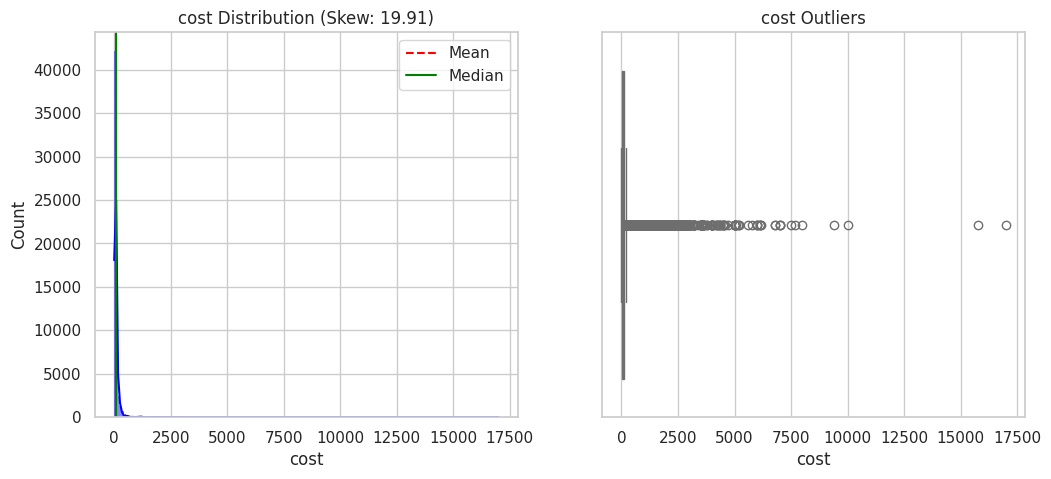

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(num_cols)

col = "cost"

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df[col],kde=True,color='blue')
plt.axvline(df[col].mean(), color = 'red', linestyle='--',label='Mean')
plt.axvline(df[col].median(),color ='green',linestyle='-', label='Median')
plt.title(f'{col} Distribution (Skew: {df[col].skew():.2f})')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(x=df[col],color='lightcoral')
plt.title(f'{col} Outliers')
plt.show()
plt.show()

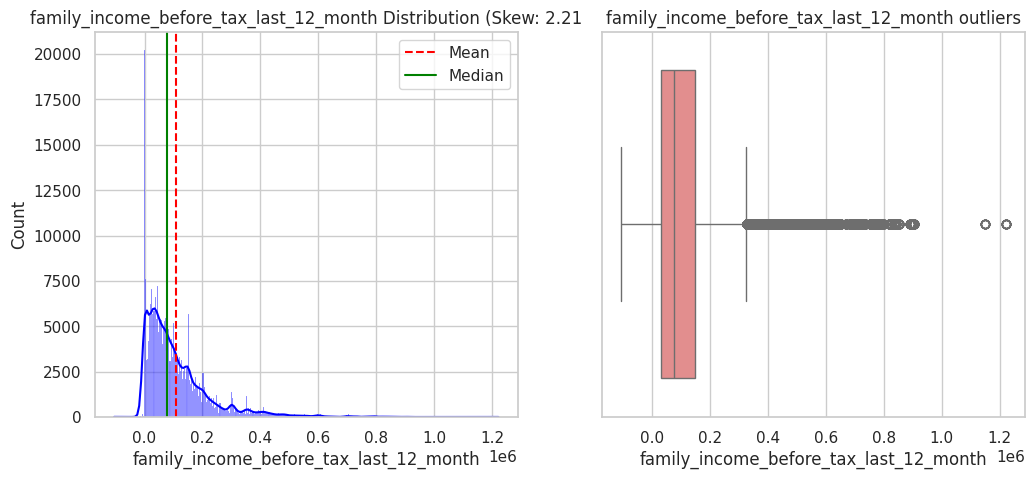

In [11]:
col_target = "family_income_before_tax_last_12_month"

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df[col_target],kde=True,color='blue')
plt.axvline(df[col_target].mean(),color='red',linestyle='--',label='Mean')
plt.axvline(df[col_target].median(),color='green',linestyle='-',label='Median')
plt.title(f'{col_target} Distribution (Skew: {df[col_target].skew():.2f}')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(x=df[col_target],color='lightcoral')
plt.title(f'{col_target} outliers')
plt.show()
plt.show()

In [38]:
print(df[col].skew())
print(df['product_description'].head())

2.7421147128363126
0    Cable and satellite television services
1    Cable and satellite television services
2    Cable and satellite television services
3    Cable and satellite television services
4    Cable and satellite television services
Name: product_description, dtype: object


2. Categorical variables

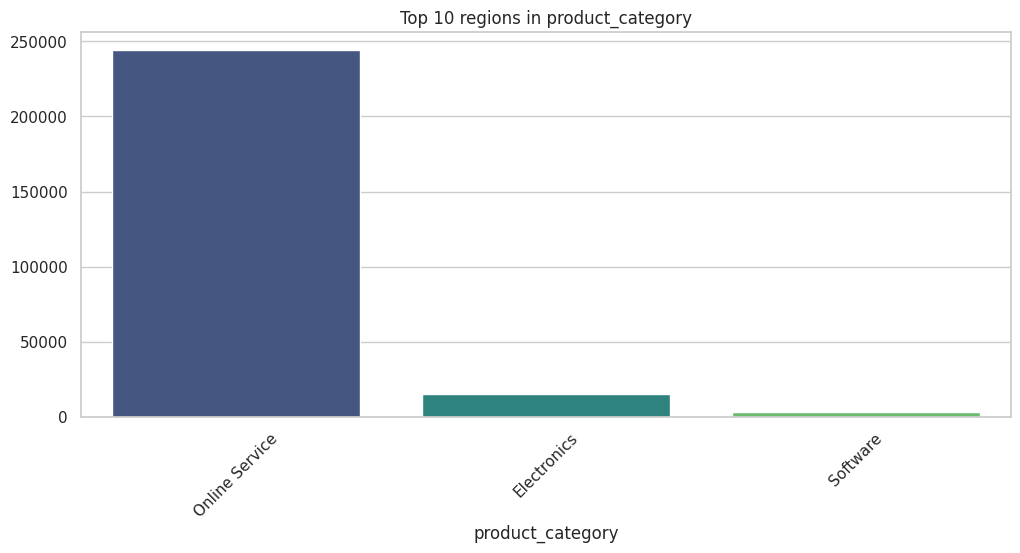

Vital few categories: 1/3 (33.33%)
They cover exactly 85.00% as the target threshold (actual coverage will be >= 85.00%).
product_category
Online Service    92.99 %
product_category
Online Service    244076
Electronics        15026
Software            3365
Name: count, dtype: int64


In [12]:
cat_col = 'product_category'

counts = df[cat_col].value_counts()
points = df[cat_col].value_counts(normalize=True)
cum_sum = points.cumsum()

plt.figure(figsize=(12,5))
sns.barplot(x=counts.index[:10],y=counts.values[:10],palette='viridis')
plt.title(f'Top 10 regions in {cat_col}')
plt.xticks(rotation=45)
plt.show()
threshold = 0.85
vital_few = cum_sum[cum_sum <= threshold]

# add the first category that crosses the threshold (if it exists)
if len(vital_few) < len(cum_sum):
    vital_few = cum_sum.iloc[:len(vital_few)+1]

portion_pct = (len(vital_few) / len(counts)) * 100

print(f"Vital few categories: {len(vital_few)}/{len(counts)} ({portion_pct:.2f}%)")
print(f"They cover exactly {threshold*100:.2f}% as the target threshold (actual coverage will be >= {threshold*100:.2f}%).")
vital_few_pct = (vital_few * 100).round(2)
print(vital_few_pct.to_string() + " %")
print(counts)



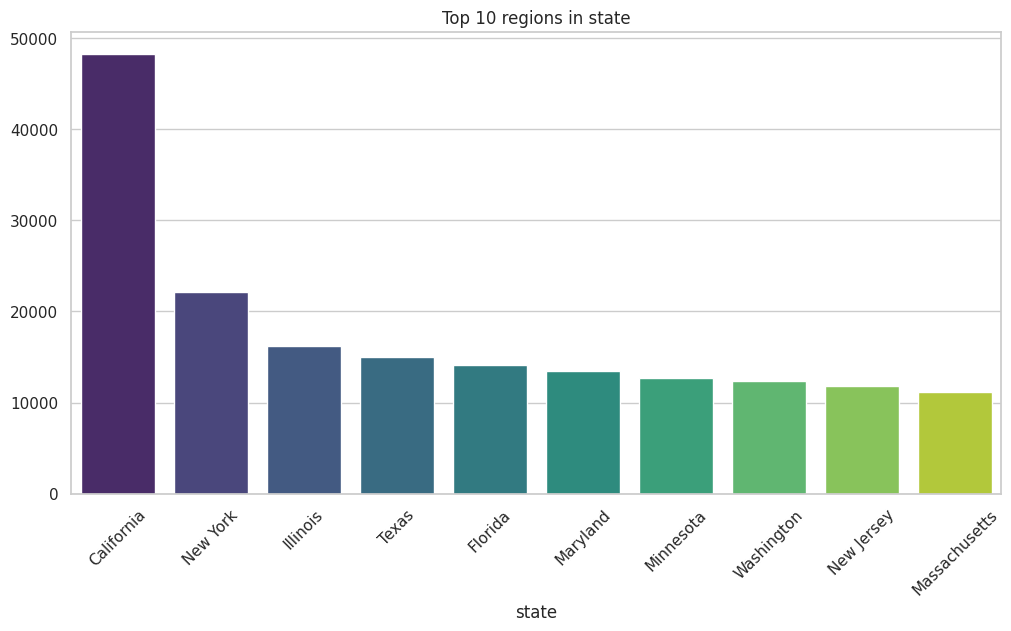

Vital region categories: 14/23 (60.87%)
state
California       18.40
New York         26.83
Illinois         33.02
Texas            38.73
Florida          44.12
Maryland         49.26
Minnesota        54.11
Washington       58.82
New Jersey       63.34
Massachusetts    67.59
Colorado         71.78
Michigan         75.86
Alaska           79.80
Hawaii           83.73 %
state
California              48282
New York                22146
Illinois                16243
Texas                   14974
Florida                 14144
Maryland                13505
Minnesota               12730
Washington              12367
New Jersey              11865
Massachusetts           11143
Colorado                10988
Michigan                10713
Alaska                  10354
Hawaii                  10301
Missouri                10020
Georgia                  8888
Arizona                  7101
Virginia                 6212
Pennsylvania             5852
District of Columbia     1493
Indiana                 

In [13]:
cat_region = 'state'

region_count = df[cat_region].value_counts()
region_pct = df[cat_region].value_counts(normalize=True)
cumulative_region = region_pct.cumsum()

plt.figure(figsize=(12,6))
sns.barplot(x=region_count.head(10).index,y=region_count.head(10).values, palette='viridis')
plt.xticks(rotation=45)
plt.title(f'Top 10 regions in {cat_region}')
plt.show()

threshold = 0.85
vital_region = cumulative_region[cumulative_region <= threshold]

if len(vital_region) < len(cumulative_region):
    rank_region = cumulative_region.iloc[:len(vital_region)+1]

region_portion = (len(vital_region) / len(region_count)) * 100

print(f"Vital region categories: {len(vital_region)}/{len(region_count)} ({region_portion:.2f}%)")
vital_region_pct = (vital_region * 100).round(2)
print(vital_region_pct.to_string() + " %")
print(region_count)

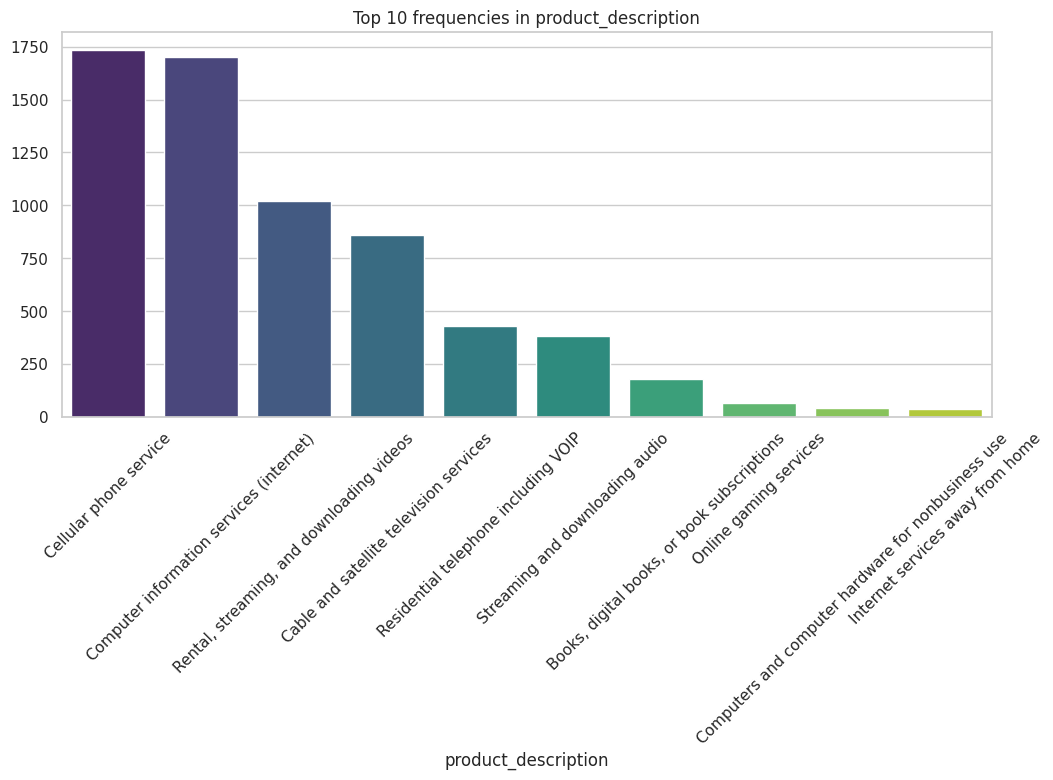

Vital product categories: 5/32 (15.62%)
They cover exactly 85.00% as the target threshold (actual coverage will be >= 85.00%).
product_description
Cellular phone service                       25.41
Computer information services (internet)     50.38
Rental, streaming, and downloading videos    65.35
Cable and satellite television services      77.99
Residential telephone including VOIP         84.27 %
product_description
Cellular phone service                                     1733
Computer information services (internet)                   1703
Rental, streaming, and downloading videos                  1021
Cable and satellite television services                     862
Residential telephone including VOIP                        428
Streaming and downloading audio                             381
Books, digital books, or book subscriptions                 177
Online gaming services                                       68
Computers and computer hardware for nonbusiness use          41


In [14]:
cat_product = 'product_description'

cat_count = df[cat_product].value_counts()
cat_points = df[cat_product].value_counts(normalize=True)
cumulative_pct = cat_points.cumsum()

plt.figure(figsize=(12,5))
sns.barplot(x=cat_count.head(10).index,y=cat_count.head(10).values,palette='viridis')
plt.xticks(rotation=45)
plt.title(f'Top 10 frequencies in {cat_product}')
plt.show()

threshold = 0.85
vital_product = cumulative_pct[cumulative_pct <= threshold]

# add the first category that crosses the threshold (if it exists)
if len(vital_product) < len(cumulative_pct):
    vital_few = cumulative_pct.iloc[:len(vital_product)+1]

product_portion = (len(vital_product) / len(cat_count)) * 100

print(f"Vital product categories: {len(vital_product)}/{len(cat_count)} ({product_portion:.2f}%)")
print(f"They cover exactly {threshold*100:.2f}% as the target threshold (actual coverage will be >= {threshold*100:.2f}%).")
vital_product_pct = (vital_product * 100).round(2)
print(vital_product_pct.to_string() + " %")
print(cat_count)




Step 5: Bivariate analysis
How do variables or columns in our dataset interact ? how are they related ?
1.Numerical vs Numerical(Correlation)

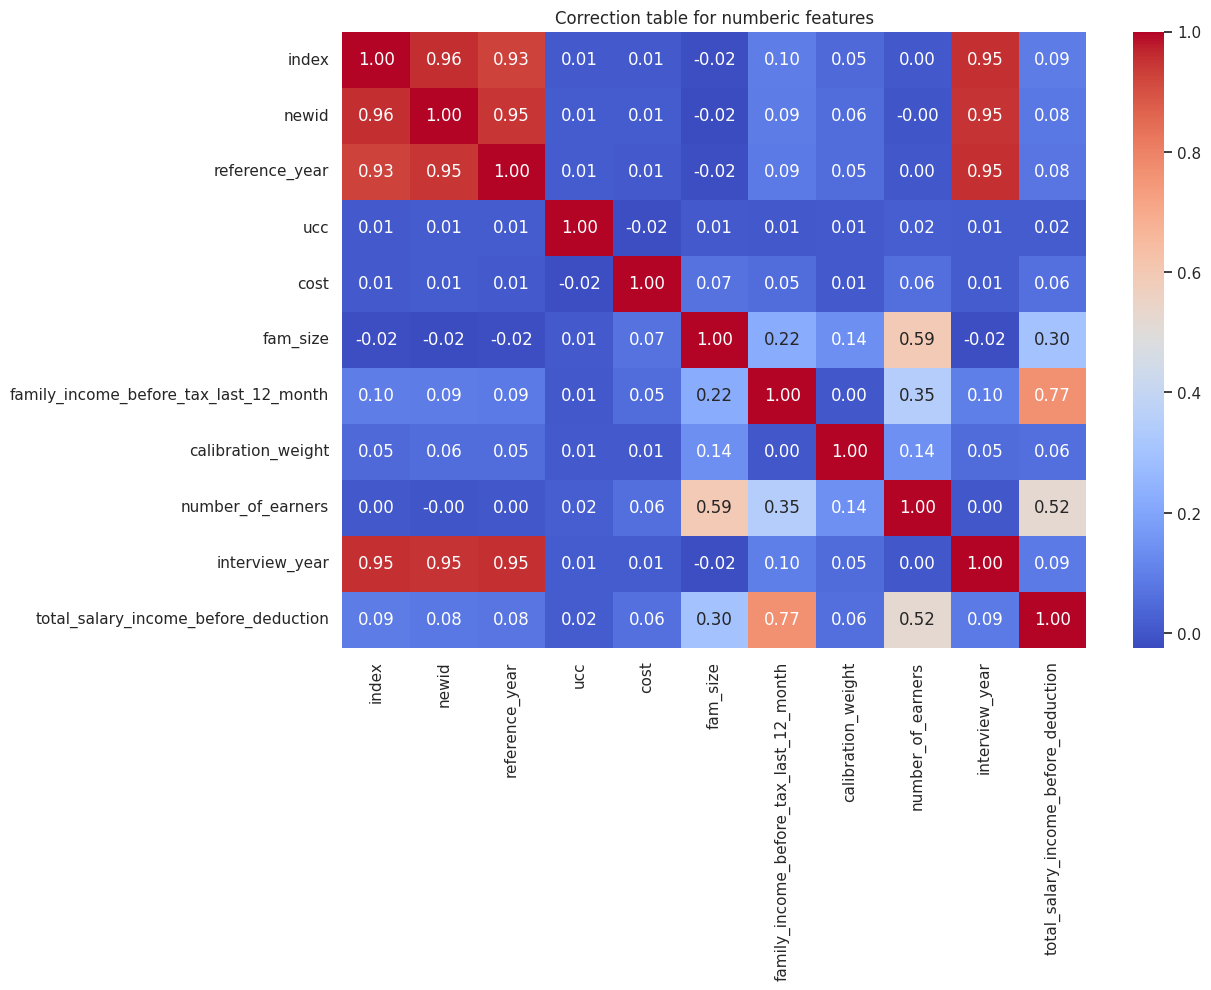

In [14]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correction table for numberic features")
plt.show()

2. Categorical vs Numerical

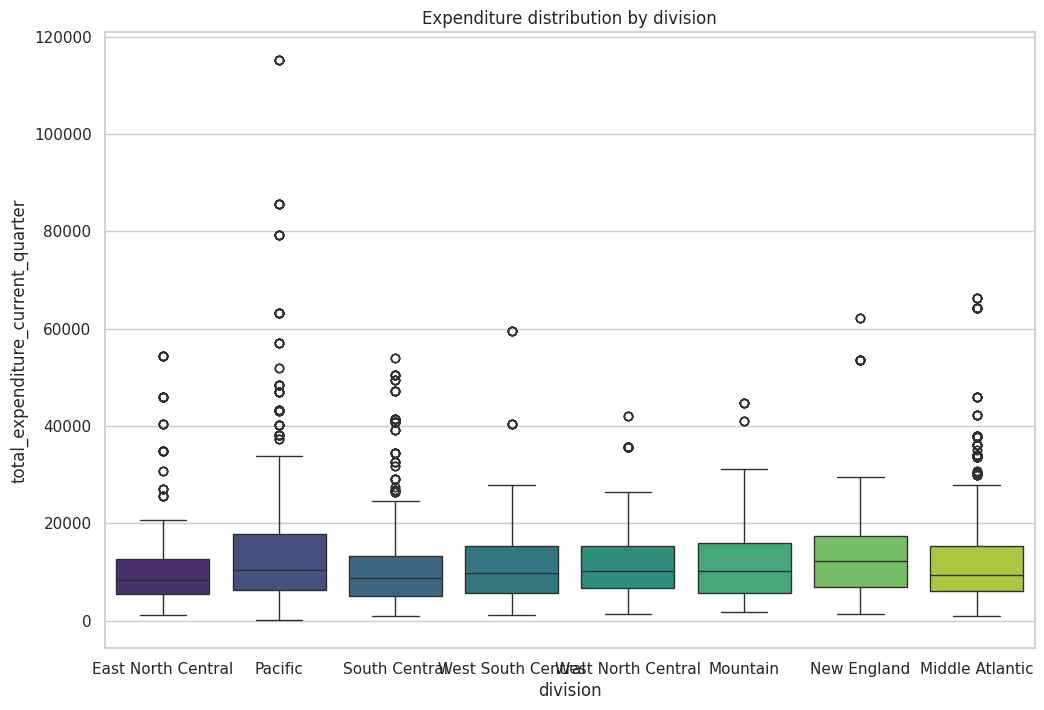

In [44]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x='division',y='total_expenditure_current_quarter',palette='viridis')
plt.title("Expenditure distribution by division")
plt.show()

In [15]:
print(df.head())

   index    newid reference_month  reference_year     ucc  cost  fam_size  \
0     29  4214954         January            2020  270102    45         1   
1     30  4214954        February            2020  270102    45         1   
2     31  4214954           March            2020  270102    45         1   
3     32  4214954         January            2020  690114   120         1   
4     33  4214954        February            2020  690114   120         1   

   family_income_before_tax_last_12_month  calibration_weight  \
0                                   10000           23581.165   
1                                   10000           23581.165   
2                                   10000           23581.165   
3                                   10000           23581.165   
4                                   10000           23581.165   

   number_of_earners interview_month  interview_year region sex_ref  \
0                  1           April            2020   West    Male   
1   